# 01 — Data Exploration

**Purpose of this notebook:** *"What data do we actually have?"*

This is a first-look notebook. We load the raw, already-cleaned dataset and inspect it
structurally — shape, columns, types, missing values, duplicates, and basic distributions.
We do **not** perform heavy preprocessing or feature engineering here — that happens in
`04_feature_engineering.ipynb`. We also do not assume any column exists before checking it.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


## 2. Load the cleaned dataset
We load directly from `data/raw/` — this notebook does not modify or save anything.

In [2]:
DATA_PATH = '../data/raw/Data__Engagement.csv'
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")


Loaded 3025 rows and 22 columns.


## 3. First rows

In [3]:
df.head(10)

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified,Flag_Engagement_Above_Views,Flag_Engagement_Rate_Outlier
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False,False,False
1,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True,False,False
2,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False,False,False
3,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False,False,True
4,POST_04605,2024-01-02 20:22:00,TikTok,Video,Travel,18977,966,2147,8088,2235,241082,9.16,20,Tuesday,5,369,Negative,Macro,False,False,True,False
5,POST_02119,2024-01-02 21:41:00,Instagram,Carousel,Entertainment,1874,467,16,30977,688,67464,3.49,21,Tuesday,11,1458,Positive,Mid-tier,True,True,False,False
6,POST_00401,2024-01-02 21:55:00,Instagram,Photo,Business,1867,125,281,44911,286,292298,0.78,21,Tuesday,6,1262,Negative,Macro,True,False,False,False
7,POST_03162,2024-01-03 04:16:00,Instagram,Reel,Education,8387,360,179,13360,945,499770,1.79,4,Wednesday,20,172,Neutral,Macro,True,False,False,False
8,POST_00426,2024-01-03 09:46:00,Facebook,Video,Sports,5540,375,632,73879,402,487579,1.34,9,Wednesday,15,353,Neutral,Macro,True,False,False,False
9,POST_00363,2024-01-03 13:28:00,Facebook,Post,Technology,1048,256,457,75334,393,29036,6.06,13,Wednesday,29,1717,Negative,Micro,True,False,False,False


## 4. Dataset shape

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 3025
Columns: 22


## 5. Column names

In [5]:
list(df.columns)

['Post_ID',
 'Timestamp',
 'Platform',
 'Content_Type',
 'Category',
 'Likes',
 'Comments',
 'Shares',
 'Views',
 'Saves',
 'Follower_Count',
 'Engagement_Rate',
 'Hour_of_Day',
 'Day_of_Week',
 'Hashtag_Count',
 'Content_Length',
 'Sentiment',
 'Influencer_Tier',
 'Has_Media',
 'Is_Verified',
 'Flag_Engagement_Above_Views',
 'Flag_Engagement_Rate_Outlier']

## 6. Data types

In [6]:
df.dtypes

Post_ID                             str
Timestamp                           str
Platform                            str
Content_Type                        str
Category                            str
Likes                             int64
Comments                          int64
Shares                            int64
Views                             int64
Saves                             int64
Follower_Count                    int64
Engagement_Rate                 float64
Hour_of_Day                       int64
Day_of_Week                         str
Hashtag_Count                     int64
Content_Length                    int64
Sentiment                           str
Influencer_Tier                     str
Has_Media                          bool
Is_Verified                        bool
Flag_Engagement_Above_Views        bool
Flag_Engagement_Rate_Outlier       bool
dtype: object

## 7. Missing-value check

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False)


,missing_count,missing_pct


In [8]:
if missing.sum() == 0:
    print("No missing values found in any column.")
else:
    print(f"Total missing cells: {missing.sum()}")


No missing values found in any column.


## 8. Duplicate check

In [9]:
full_dupes = df.duplicated().sum()
id_dupes = df['Post_ID'].duplicated().sum() if 'Post_ID' in df.columns else 'Post_ID column not found'
print(f"Fully duplicated rows: {full_dupes}")
print(f"Duplicated Post_ID values: {id_dupes}")


Fully duplicated rows: 0
Duplicated Post_ID values: 0


## 9. Unique values (categorical columns)
We check the actual categorical columns rather than assuming what they contain.

In [10]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Categorical / boolean columns found:", categorical_cols)

for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"\n--- {col} ({n_unique} unique values) ---")
    print(df[col].value_counts())


Categorical / boolean columns found: ['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified', 'Flag_Engagement_Above_Views', 'Flag_Engagement_Rate_Outlier']

--- Post_ID (3025 unique values) ---
Post_ID
POST_04552    1
POST_00210    1
POST_01548    1
POST_01350    1
POST_04605    1
             ..
POST_00816    1
POST_02703    1
POST_03265    1
POST_04388    1
POST_03668    1
Name: count, Length: 3025, dtype: int64

--- Timestamp (3021 unique values) ---
Timestamp
2024-01-12 20:49:00    2
2024-03-26 09:38:00    2
2025-03-20 20:27:00    2
2025-11-20 22:51:00    2
2024-01-01 01:42:00    1
                      ..
2025-12-31 14:05:00    1
2025-12-31 16:07:00    1
2025-12-31 18:37:00    1
2025-12-31 20:07:00    1
2025-12-31 21:56:00    1
Name: count, Length: 3021, dtype: int64

--- Platform (3 unique values) ---
Platform
Instagram    1283
Facebook      984
TikTok        758
Name: count, dtype: int64

--- Con

C:\Users\USER\AppData\Local\Temp\ipykernel_20824\774606734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


## 10. Descriptive statistics (numerical columns)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Likes,3025.0,9910.899174,11944.962957,35.00,2914.00,5739.00,9047.00,49949.00
Comments,3025.0,422.275041,462.769564,3.00,137.00,273.00,435.00,1999.00
Shares,3025.0,851.301818,1210.354518,2.00,138.00,280.00,870.00,4997.00
Views,3025.0,86901.163306,121208.993566,551.00,19576.00,38651.00,72320.00,497812.00
Saves,3025.0,742.953058,683.684526,8.00,296.00,558.00,868.00,2999.00
Follower_Count,3025.0,247475.622810,144998.877310,543.00,122702.00,242641.00,373219.00,499815.00
Engagement_Rate,3025.0,16.258522,90.214362,0.06,1.42,3.01,8.52,3510.46
Hour_of_Day,3025.0,11.510083,6.919223,0.00,5.00,12.00,18.00,23.00
Hashtag_Count,3025.0,14.532893,8.668669,0.00,7.00,15.00,22.00,29.00
Content_Length,3025.0,657.365950,548.272956,15.00,236.00,465.00,1021.00,1999.00


## 11. Platform distribution
The project's target platforms are TikTok, Instagram, and Facebook. Let's confirm which
platforms actually exist in the data.

Column 'Platform' found: True
Platform
Instagram    1283
Facebook      984
TikTok        758
Name: count, dtype: int64


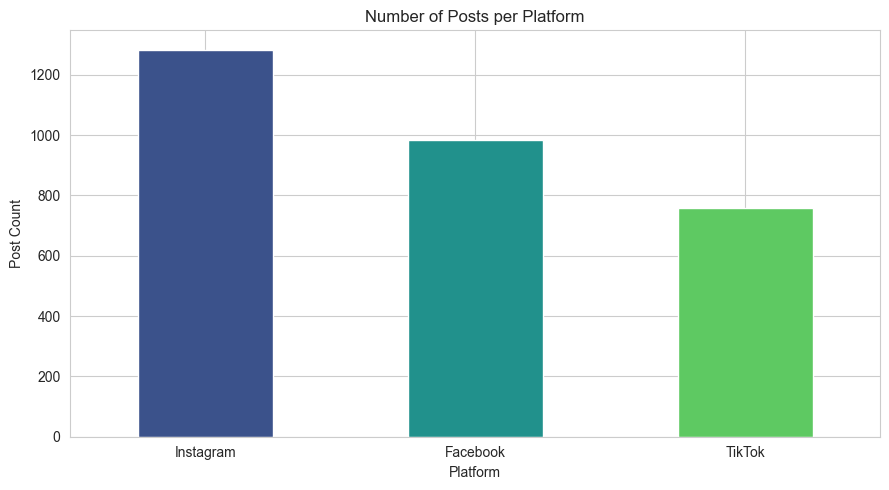

In [12]:
print("Column 'Platform' found:", 'Platform' in df.columns)
if 'Platform' in df.columns:
    platform_counts = df['Platform'].value_counts()
    print(platform_counts)
    ax = platform_counts.plot(kind='bar', color=sns.color_palette('viridis', len(platform_counts)))
    ax.set_title('Number of Posts per Platform')
    ax.set_xlabel('Platform')
    ax.set_ylabel('Post Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("THIS FEATURE IS NOT AVAILABLE IN THE DATASET.")


## 12. Category / topic distribution

Category
Gaming           297
Technology       273
Entertainment    264
Food             256
Lifestyle        255
Health           251
Education        250
Fashion          249
Sports           245
Fitness          240
Business         224
Travel           221
Name: count, dtype: int64


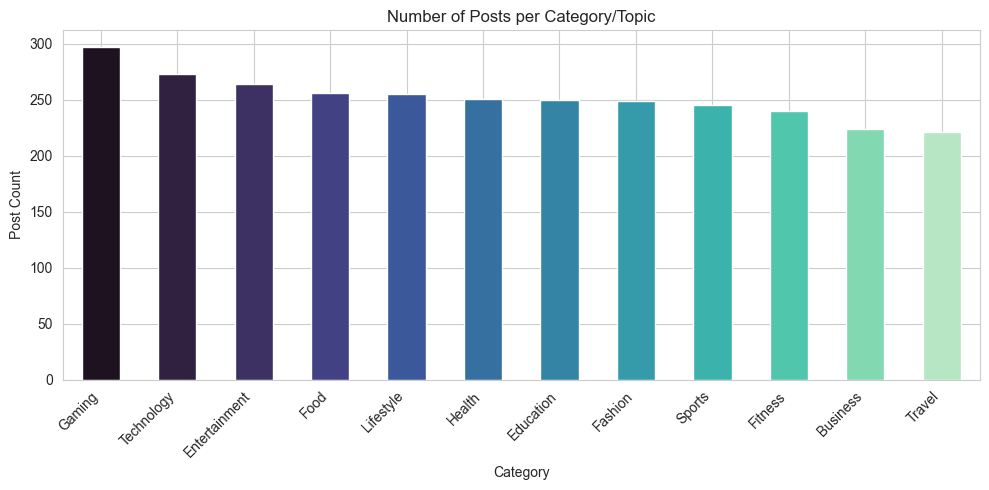

In [13]:
if 'Category' in df.columns:
    cat_counts = df['Category'].value_counts()
    print(cat_counts)
    ax = cat_counts.plot(kind='bar', figsize=(10, 5), color=sns.color_palette('mako', len(cat_counts)))
    ax.set_title('Number of Posts per Category/Topic')
    ax.set_xlabel('Category')
    ax.set_ylabel('Post Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("THIS FEATURE IS NOT AVAILABLE IN THE DATASET.")


## 13. Content-type distribution

Content_Type
Story       568
Video       512
Carousel    333
Photo       320
Reel        306
Stitch      259
Duet        248
Post        240
Live        239
Name: count, dtype: int64


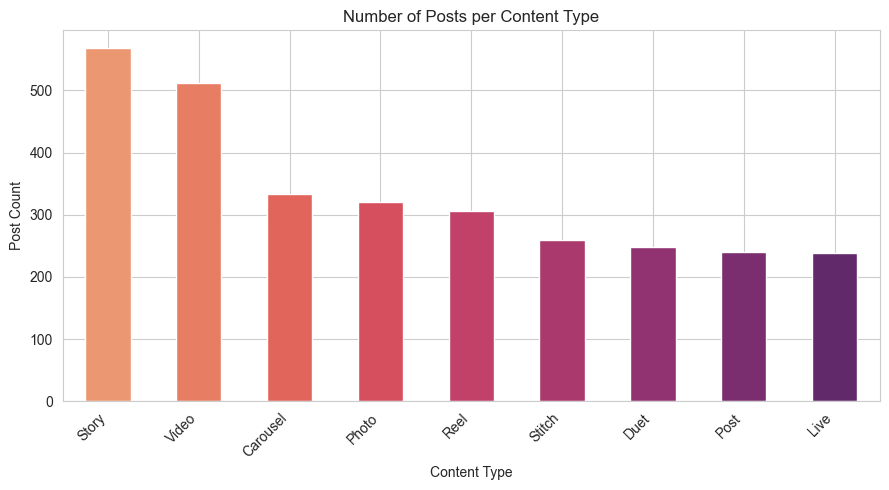


NOTE: Content_Type appears to vary by platform (e.g. 'Reel' only exists on Instagram).
We verify this with a cross-tabulation:


Content_Type,Carousel,Duet,Live,Photo,Post,Reel,Stitch,Story,Video
Platform,,,,,,,,,
Facebook,0,0,239,0,240,0,0,244,261
Instagram,333,0,0,320,0,306,0,324,0
TikTok,0,248,0,0,0,0,259,0,251


In [14]:
if 'Content_Type' in df.columns:
    ct_counts = df['Content_Type'].value_counts()
    print(ct_counts)
    ax = ct_counts.plot(kind='bar', figsize=(9, 5), color=sns.color_palette('flare', len(ct_counts)))
    ax.set_title('Number of Posts per Content Type')
    ax.set_xlabel('Content Type')
    ax.set_ylabel('Post Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\nNOTE: Content_Type appears to vary by platform (e.g. 'Reel' only exists on Instagram).")
    print("We verify this with a cross-tabulation:")
    display(pd.crosstab(df['Platform'], df['Content_Type']))
else:
    print("THIS FEATURE IS NOT AVAILABLE IN THE DATASET.")


## 14. Engagement-related variables
We check which columns describe post performance (these are our candidate targets / post-publication variables, handled carefully later for data leakage).

In [15]:
engagement_like_cols = [c for c in df.columns if any(k in c.lower() for k in
                        ['like', 'comment', 'share', 'view', 'save', 'engagement'])]
print("Engagement-related columns found:", engagement_like_cols)
df[engagement_like_cols].describe().T


Engagement-related columns found: ['Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Engagement_Rate', 'Flag_Engagement_Above_Views', 'Flag_Engagement_Rate_Outlier']


,count,mean,std,min,25%,50%,75%,max
Likes,3025.0,9910.899174,11944.962957,35.00,2914.00,5739.00,9047.00,49949.00
Comments,3025.0,422.275041,462.769564,3.00,137.00,273.00,435.00,1999.00
Shares,3025.0,851.301818,1210.354518,2.00,138.00,280.00,870.00,4997.00
Views,3025.0,86901.163306,121208.993566,551.00,19576.00,38651.00,72320.00,497812.00
Saves,3025.0,742.953058,683.684526,8.00,296.00,558.00,868.00,2999.00
Engagement_Rate,3025.0,16.258522,90.214362,0.06,1.42,3.01,8.52,3510.46


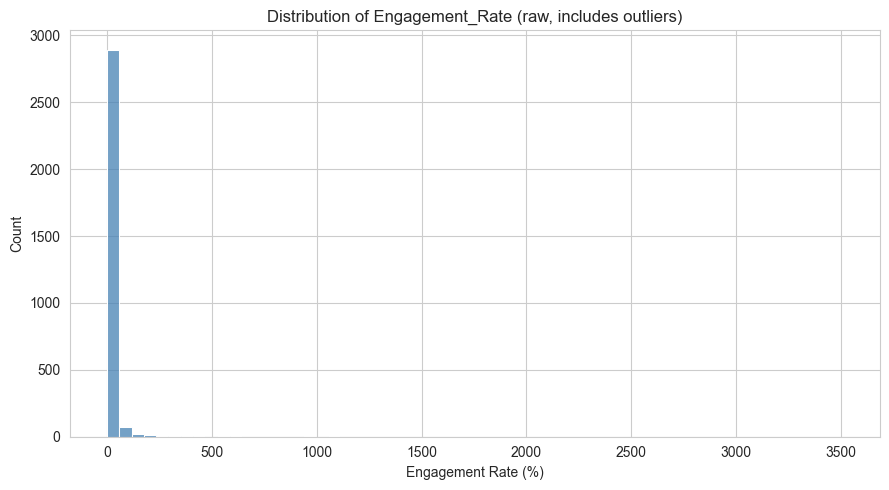

count    3025.000000
mean       16.258522
std        90.214362
min         0.060000
25%         1.420000
50%         3.010000
75%         8.520000
max      3510.460000
Name: Engagement_Rate, dtype: float64


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['Engagement_Rate'], bins=60, ax=ax, color='steelblue')
ax.set_title('Distribution of Engagement_Rate (raw, includes outliers)')
ax.set_xlabel('Engagement Rate (%)')
plt.tight_layout()
plt.show()

print(df['Engagement_Rate'].describe())


## Caption / hashtag / date-time columns check
The project also asks us to check for caption text, hashtag text, and date/time columns.

In [17]:
text_like = [c for c in df.columns if any(k in c.lower() for k in ['caption', 'text', 'hashtag'])]
print("Caption/hashtag-like columns:", text_like)

date_like = [c for c in df.columns if any(k in c.lower() for k in ['time', 'date', 'hour', 'day', 'month'])]
print("Date/time-like columns:", date_like)


Caption/hashtag-like columns: ['Hashtag_Count']
Date/time-like columns: ['Timestamp', 'Hour_of_Day', 'Day_of_Week', 'Sentiment']


In [18]:
print("--- Column-by-column check against project assumptions ---")
checks = {
    'caption text column (actual written caption)': any('caption' in c.lower() for c in df.columns),
    'hashtag text column (actual hashtags used)': any(c.lower() == 'hashtags' or 'hashtag_text' in c.lower() for c in df.columns),
    'real posting hour': 'Hour_of_Day' in df.columns,
    'follower count': 'Follower_Count' in df.columns,
}
for feature, available in checks.items():
    status = "AVAILABLE" if available else "THIS FEATURE IS NOT AVAILABLE IN THE DATASET."
    print(f"- {feature}: {status}")


--- Column-by-column check against project assumptions ---
- caption text column (actual written caption): THIS FEATURE IS NOT AVAILABLE IN THE DATASET.
- hashtag text column (actual hashtags used): THIS FEATURE IS NOT AVAILABLE IN THE DATASET.
- real posting hour: AVAILABLE
- follower count: AVAILABLE


## Summary of Notebook 01

**What data do we actually have?**

- The dataset contains **3,025 rows** and **22 columns**, with **no missing values** and
  **no duplicate rows** (checked both on full-row duplicates and on `Post_ID`).
- Three platforms are present: **Instagram, Facebook, TikTok** — matching the project's target platforms.
- `Content_Type` is **platform-specific** (e.g. TikTok has Duet/Stitch, Instagram has Reel/Carousel, Facebook has Live/Post)
  — this needs to be handled carefully in feature engineering / modeling.
- We have real `Hour_of_Day` and `Day_of_Week` columns derived from an actual `Timestamp`, so posting-time analysis is supported.
- We have `Follower_Count` and `Influencer_Tier`.
- We have **no actual caption text** and **no actual hashtag text** — only `Hashtag_Count` (a number) and `Content_Length`
  (a number, presumably character length of the caption/content). This is a real limitation for the
  Caption & Hashtag Analysis feature and is documented later in **Dataset Limitations**.
- `Engagement_Rate` is heavily right-skewed with extreme outliers (max ≈ 3510% vs. median ≈ 3%), which we
  will need to handle carefully when defining the Low/Medium/High target in notebook 04.

Next: `02_data_cleaning.ipynb` — validation of this already-cleaned dataset.